# 04b — Coupled (V, T, C) SDE on the GPU (JAX)

JAX `vmap` + `jit` implementation of the coupled power-thermal-cyber SDE from paper §10 eq. (11), running on the RTX 5090.
Compare against the NumPy baseline in `notebooks/04_sde_simulation_cpu.ipynb`.

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
import jax
from dcrisk.sde.ptcyber import simulate_ptcyber
from dcrisk.sde.ptcyber_gpu import simulate_ptcyber_gpu
print('JAX devices:', jax.devices())

JAX devices: [CudaDevice(id=0)]


In [2]:
# Quick warmup so jit-compilation is not counted in the timing.
_ = simulate_ptcyber_gpu(T_max=0.5, dt=1/60.0, n_paths=64)

t0 = time.perf_counter(); t, X_gpu = simulate_ptcyber_gpu(T_max=24.0, dt=1/60.0, n_paths=4096); t_gpu = time.perf_counter() - t0
t0 = time.perf_counter(); _, X_cpu = simulate_ptcyber(T_max=24.0, dt=1/60.0, n_paths=256, rng=np.random.default_rng(0)); t_cpu_small = time.perf_counter() - t0
print(f'GPU (4096 paths, 24 h): {t_gpu*1000:.1f} ms')
print(f'CPU ( 256 paths, 24 h): {t_cpu_small*1000:.1f} ms')

GPU (4096 paths, 24 h): 693.9 ms
CPU ( 256 paths, 24 h): 36.7 ms


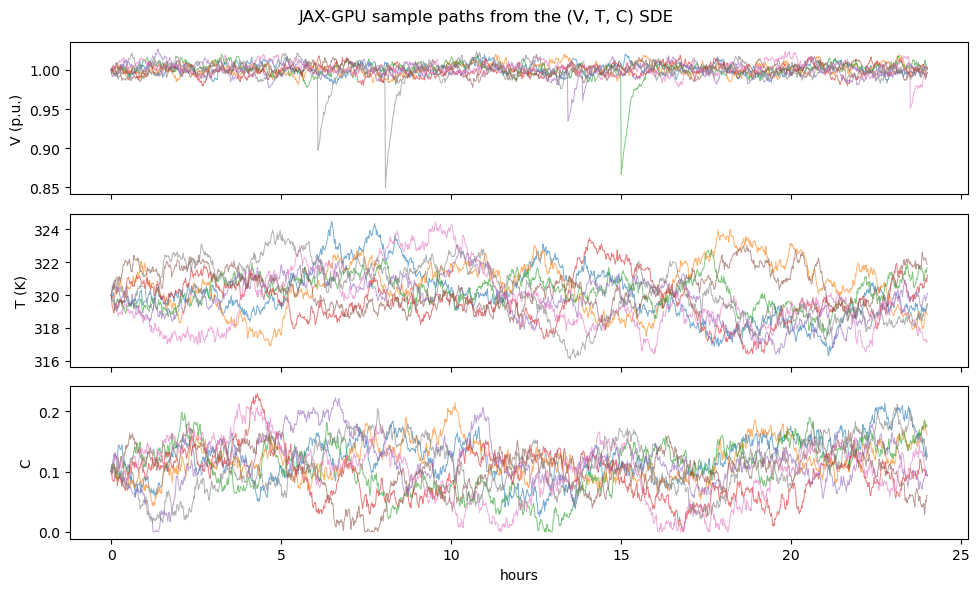

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(10, 6), sharex=True)
for k, (ax, name) in enumerate(zip(axes, ['V (p.u.)', 'T (K)', 'C'])):
    for p in range(8):
        ax.plot(t, X_gpu[p, :, k], lw=0.7, alpha=0.6)
    ax.set_ylabel(name)
axes[-1].set_xlabel('hours')
fig.suptitle('JAX-GPU sample paths from the (V, T, C) SDE')
fig.tight_layout(); fig.savefig('fig_04b_sde_gpu.png', dpi=150)
plt.show()